<a href="https://colab.research.google.com/github/gigs-codes/Practicing-machine-learning/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from sklearn.datasets import load_iris

In [3]:
# loading data
def load_data():
  data=load_iris()
  X = pd.DataFrame(data.data, columns=data.feature_names)
  y = pd.Series(data.target)
  return X, y

X, y = load_data()

In [4]:
# data cleaning
def clean_data(X):
  # fill missing values
  X = X.fillna(X.mean())

  # remove duplicates
  X = X.drop_duplicates()

  return X

In [5]:
# scale features - make all features comparable
from sklearn.preprocessing import StandardScaler
def scale_feature(X_train, X_test):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  return X_train_scaled, X_test_scaled

In [6]:
# feature engineering - you are creating new intelligence from data
def add_feature(X):
  X=X.copy()
  X['petal ratio'] = X['petal length (cm)'] / X['petal width (cm)']
  return X

In [7]:
# feature selection
from sklearn.feature_selection import SelectKBest, f_classif

def select_feature(X, y, k=2):
  selector = SelectKBest(score_func=f_classif, k=k)
  X_new = X.fit_transform(X, y)
  return X_new

In [8]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
# EDA - exploratory data analysis
import matplotlib.pyplot as plt

def plot_feature(X, y):
    plt.scatter(X.iloc[:, 2], X.iloc[:, 3], c=y)
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.show()

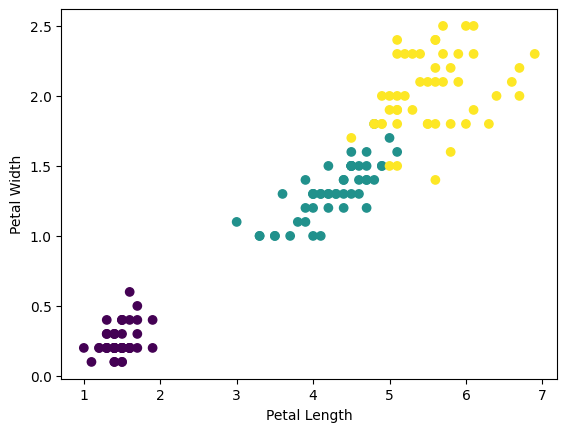

In [10]:
plot_feature(X, y)
# call the function explicitly

In [11]:
import matplotlib.pyplot as plt

import numpy as np
def plot_features_with_label(X, y):
  # petal length
  x1 = X.iloc[:, 2]
  # petal width
  x2 = X.iloc[:, 3]

  scatter = plt.scatter(x1, x2, c=y)

  plt.xlabel("petal length")
  plt.ylabel("petal width")

  # legends label
  classes = ["Setosa", "Versicolor", "Virginica"]

  plt.legend(handles = scatter.legend_elements()[0], labels= classes)

  plt.title("Iris dataset (Petal features)")
  plt.show()

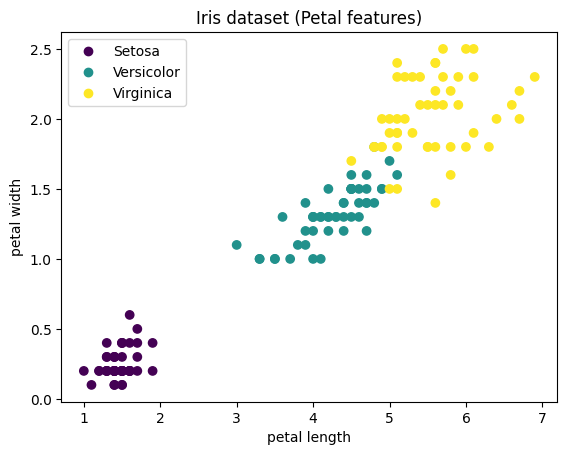

In [12]:
plot_features_with_label(X, y)

In [13]:
# add a decision boundary in it
from sklearn.linear_model import LogisticRegression

def plot_decision_boundary(X, y):
  X_plot = X.iloc[:, [2,3]]

  model = LogisticRegression()
  model.fit(X_plot, y)

  # create mesh grid
  x_min, x_max = X_plot.iloc[:, 0].min() - 1, X_plot.iloc[:, 0].max() + 1
  y_min, y_max = X_plot.iloc[:, 1].min() - 1, X_plot.iloc[:, 1].max() + 1

  xx, yy = np.meshgrid(
      np.linspace(x_max, x_min, 200),
      np.linspace(y_min, y_max, 200)
  )

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # plot boundary
  plt.contourf(xx, yy, Z, alpha = 0.3)
  # plot points
  scatter = plt.scatter(X_plot.iloc[:,0], X_plot.iloc[:, 1], c=y)
  # labels
  classes = ["setosa", "versicolor", "virginica"]
  plt.legends(handles = scatter.legend_elements()[0], labels=classes)

  plt.xlabel("petal length")
  plt.ylabel("petal width")
  plt.title("decision boundary (logistic regression)")

  plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


AttributeError: module 'matplotlib.pyplot' has no attribute 'legends'

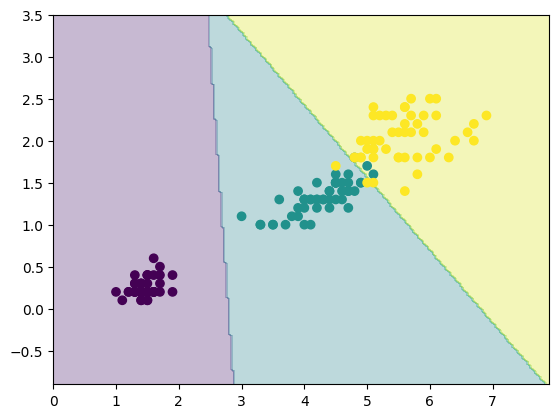

In [14]:
plot_decision_boundary(X, y)

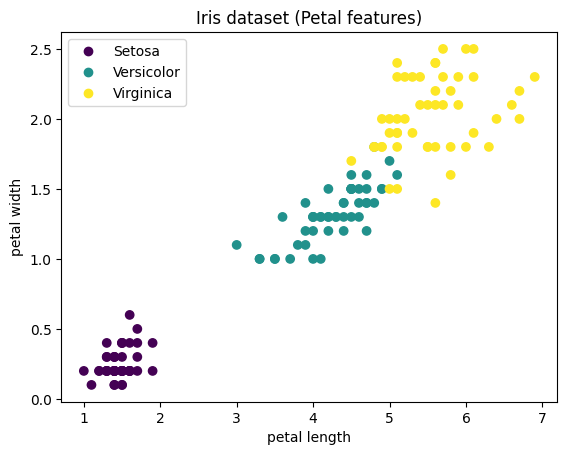

In [15]:
plot_features_with_label(X, y)

In [16]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred):
  print("Confusion matrix : \n", confusion_matrix(y_true, y_pred))
  print("\n Report: \n", classification_report(y_true, y_pred))